<a href="https://colab.research.google.com/github/TRZs69/machine-learning-evaluation/blob/main/chatbot_ml_evaluation%20(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM as a Judge

In [ ]:

# ── Google Drive Mount & Persistent Storage Setup ──────────────────────────
# Run this cell once per session. All checkpoint and output files will be
# saved to Google Drive so they survive runtime resets.

from google.colab import drive
import os

drive.mount('/content/drive')

# Change this folder path if needed
GDRIVE_FOLDER = '/content/drive/MyDrive/levelearn_eval'
os.makedirs(GDRIVE_FOLDER, exist_ok=True)

print(f'Google Drive mounted. Persistent storage folder: {GDRIVE_FOLDER}')


In [ ]:
# ---------------------------------------------------------------------------
# Shared Utilities
# Run this cell once before any other code cells. All helper functions used
# across multiple cells are defined here to avoid duplication.
# ---------------------------------------------------------------------------
import json
import time
import requests
import numpy as np
import pandas as pd
from google.colab import userdata


# ── Cochran + FPC sampling ──────────────────────────────────────────

def compute_cochran_fpc_sample_size(population_n: int, z: float = 1.96, p: float = 0.5, e: float = 0.10):
    if population_n <= 0:
        return 0.0, 0
    q = 1 - p
    n0 = (z ** 2) * p * q / (e ** 2)
    n_fpc = n0 / (1 + ((n0 - 1) / population_n))
    return n0, int(np.round(n_fpc))


def sample_equal_allocation_pairs(df: 'pd.DataFrame', target_n: int, random_state: int = 42) -> 'pd.DataFrame':
    if target_n <= 0 or df.empty:
        return df.head(0).copy()

    if 'user_id' not in df.columns:
        raise ValueError("Input dataframe must contain 'user_id'.")

    rng = np.random.default_rng(random_state)
    data = df.copy()
    data['user_id'] = data['user_id'].astype(str)

    user_index_pool = {}
    for user_id, grp in data.groupby('user_id', sort=False):
        idx = grp.index.to_list()
        rng.shuffle(idx)
        user_index_pool[user_id] = idx

    users = list(user_index_pool.keys())
    selected_indices = []
    used_count = {u: 0 for u in users}

    if target_n <= len(users):
        chosen_users = rng.choice(users, size=target_n, replace=False)
        for u in chosen_users:
            selected_indices.append(user_index_pool[u][used_count[u]])
            used_count[u] += 1
        sampled = data.loc[selected_indices].copy()
        return sampled.sample(frac=1, random_state=random_state).reset_index(drop=True)

    for u in users:
        selected_indices.append(user_index_pool[u][used_count[u]])
        used_count[u] += 1

    remaining = target_n - len(selected_indices)
    while remaining > 0:
        eligible = [u for u in users if used_count[u] < len(user_index_pool[u])]
        if not eligible:
            break
        take_now = min(remaining, len(eligible))
        chosen_users = rng.choice(eligible, size=take_now, replace=False)
        for u in chosen_users:
            selected_indices.append(user_index_pool[u][used_count[u]])
            used_count[u] += 1
        remaining -= take_now

    sampled = data.loc[selected_indices].copy()
    return sampled.sample(frac=1, random_state=random_state).reset_index(drop=True)


# ── ELO / student profile ───────────────────────────────────────────

def infer_elo_band(elo):
    try:
        x = int(float(elo))
    except Exception:
        x = 1200

    if x < 1000:
        return 'Beginner'
    if x < 1200:
        return 'Basic Understanding'
    if x < 1400:
        return 'Developing Learner'
    if x < 1600:
        return 'Intermediate'
    if x < 1800:
        return 'Proficient'
    if x < 2000:
        return 'Advanced'
    return 'Mastery'


def build_student_profile_context(row):
    latest_elo = row.get('latest_elo', 1200)
    grade = row.get('grade', 'N/A')
    material_name = row.get('material_name', 'None')
    band = infer_elo_band(latest_elo)

    profile_fields = []
    for col in ['user_name', 'user_username', 'user_email', 'user_learning_style', 'user_target']:
        if col in row and pd.notna(row[col]) and str(row[col]).strip() != '':
            profile_fields.append(f'{col}: {row[col]}')

    profile_text = '; '.join(profile_fields) if profile_fields else 'N/A'
    return {
        'latest_elo': latest_elo,
        'elo_band': band,
        'grade': grade,
        'material_name': material_name,
        'profile_text': profile_text,
    }


def build_prompt(row):
    ctx = build_student_profile_context(row)
    return (
        'You are an educational evaluator for LeveLearn.\n'
        'Kamu adalah evaluator pedagogis untuk LeveLearn.\n'
        '\n'
        'Goal/Tujuan:\n'
        'Evaluate the chatbot response quality for this learner context.\n'
        'Nilai kualitas jawaban chatbot sesuai konteks belajar pengguna ini.\n'
        '\n'
        'LEVELEARN CONTEXT / KONTEKS LEVELEARN:\n'
        '- User ELO range / Rentang ELO pengguna: 750-3000\n'
        f'- Current ELO band / Band ELO saat ini: {ctx["elo_band"]} (latest_elo={ctx["latest_elo"]})\n'
        f'- Latest assessment grade / Nilai asesmen terbaru: {ctx["grade"]}\n'
        f'- Related material/chapter / Materi terkait: {ctx["material_name"]}\n'
        f'- User profile summary / Ringkasan profil user: {ctx["profile_text"]}\n'
        f'- Educational summary / Ringkasan edukasi: {row["educational_context_summary"]}\n'
        '\n'
        'INTERACTION / INTERAKSI:\n'
        f'User: {row["user_message"]}\n'
        f'Chatbot: {row["chatbot_reply"]}\n'
        '\n'
        'RUBRIC / RUBRIK:\n'
        'Rate the overall quality from 1 to 5 based on accuracy, personalization to learner level (ELO, grade), and pedagogical value.\n'
        'Nilai kualitas keseluruhan dari 1 hingga 5 berdasarkan akurasi, personalisasi terhadap level learner (ELO, grade), dan nilai pedagogis.\n'
        '\n'
        'Anchor definitions / Definisi anchor:\n'
        '- 1: Incorrect/harmful or ignores learner context.\n'
        '- 2: Partly correct but weak usefulness/personalization.\n'
        '- 3: Correct and helpful but generic.\n'
        '- 4: Correct, clear, and meaningfully personalized.\n'
        '- 5: Highly accurate, pedagogically strong, and strongly personalized for this learner.\n'
        '\n'
        'Important / Penting:\n'
        '- Do NOT reward verbosity alone.\n'
        '- Jangan memberi skor tinggi hanya karena jawaban panjang.\n'
        '- Prioritize correctness + pedagogical usefulness for this learner state.\n'
        '- Prioritaskan ketepatan + kemanfaatan pedagogis sesuai kondisi learner.\n'
        '\n'
        'Return ONLY valid JSON:\n'
        '{"score": <integer 1-5>, "reason": "<brief bilingual-or-Indonesian rationale>"}'
    )


# ── OpenRouter API helpers ──────────────────────────────────────────

def get_openrouter_headers():
    api_key = userdata.get('OPENROUTER_API_KEY')
    if not api_key:
        raise ValueError('OPENROUTER_API_KEY not found in Colab secrets.')

    headers = {
        'Authorization': f'Bearer {api_key}',
        'Content-Type': 'application/json',
    }

    referer = userdata.get('OPENROUTER_REFERER')
    app_name = userdata.get('OPENROUTER_APP_NAME')
    if referer:
        headers['HTTP-Referer'] = referer
    if app_name:
        headers['X-Title'] = app_name
    return headers


def strip_markdown_json(text: str) -> str:
    txt = (text or '').strip()
    if '```json' in txt:
        txt = txt.split('```json', 1)[1].split('```', 1)[0].strip()
    elif '```' in txt:
        txt = txt.split('```', 1)[1].split('```', 1)[0].strip()
    return txt


def parse_judge_json(content: str):
    data = json.loads(strip_markdown_json(content))
    score = int(float(data.get('score')))
    reason = str(data.get('reason', '')).strip()
    if score < 1 or score > 5:
        raise ValueError(f'Invalid score: {score}')
    return score, reason


def request_with_retry(payload, headers):
    """Retry wrapper for OpenRouter requests.

    Reads API_URL, REQUEST_TIMEOUT, MAX_RETRIES, RETRY_BASE_DELAY from the
    calling cell's globals so each cell can configure these independently.
    """
    _url = globals().get('API_URL', 'https://openrouter.ai/api/v1/chat/completions')
    _timeout = globals().get('REQUEST_TIMEOUT', 60)
    _max_retries = globals().get('MAX_RETRIES', 4)
    _base_delay = globals().get('RETRY_BASE_DELAY', 30)
    last_err = None
    for attempt in range(_max_retries + 1):
        try:
            response = requests.post(_url, headers=headers, json=payload, timeout=_timeout)

            if response.status_code == 200:
                return response, None

            if response.status_code == 429:
                retry_after = response.headers.get('Retry-After')
                wait = int(retry_after) if retry_after else _base_delay * (2 ** attempt)
                last_err = 'HTTP 429 Rate Limited'
                print(f'  [429] attempt={attempt + 1}/{_max_retries + 1} wait={wait}s')
                time.sleep(wait)
                continue

            if response.status_code >= 500:
                wait = _base_delay * (2 ** attempt)
                last_err = f'HTTP {response.status_code}'
                print(f'  [{response.status_code}] attempt={attempt + 1}/{_max_retries + 1} wait={wait}s')
                time.sleep(wait)
                continue

            return None, f'HTTP {response.status_code}: {response.text[:300]}'
        except Exception as e:
            last_err = str(e)
            wait = _base_delay * (2 ** attempt)
            print(f'  [Exception] attempt={attempt + 1}/{_max_retries + 1} wait={wait}s error={e}')
            time.sleep(wait)

    return None, last_err or 'Max retries exceeded'


print('Shared utilities loaded.')

## 1. Fetch Supabase Data

Tujuan:
Retrieve chat sessions and messages from Supabase to form the base interaction dataset.

In [ ]:
!pip install supabase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from supabase import create_client, Client

def fetch_all_rows(client: Client, table_name: str, page_size: int = 1000):
    rows = []
    start = 0
    while True:
        end = start + page_size - 1
        resp = client.table(table_name).select('*').range(start, end).execute()
        batch = resp.data or []
        rows.extend(batch)
        if len(batch) < page_size:
            break
        start += page_size
    return rows

from google.colab import userdata

# Initialize Supabase
SUPABASE_URL = userdata.get('SUPABASE_URL')
SUPABASE_KEY = userdata.get('SUPABASE_SERVICE_ROLE_KEY')
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

# Fetch Data
df_sessions = pd.DataFrame(fetch_all_rows(supabase, 'chat_sessions'))
df_messages = pd.DataFrame(fetch_all_rows(supabase, 'chat_messages'))

# Process Pairs
pairs = []
df_all = pd.merge(df_messages, df_sessions[['id', 'user_id']], left_on='session_id', right_on='id', how='left', suffixes=('', '_s'))
df_all = df_all.sort_values(['user_id', 'session_id', 'created_at']).reset_index(drop=True)

current_user_msg = None
for _, row in df_all.iterrows():
    if row['role'] == 'user':
        current_user_msg = row
    elif row['role'] == 'assistant' and current_user_msg is not None:
        pairs.append({
            'eval_id': f"{row['session_id']}_{row['id']}",
            'user_id': str(row['user_id']),
            'user_message': current_user_msg['content'],
            'chatbot_reply': row['content']
        })
        current_user_msg = None

df_pairs = pd.DataFrame(pairs)
print(f'Retrieved {len(df_pairs)} interaction pairs.')

Retrieved 994 interaction pairs.


In [ ]:
import re
import unicodedata

# ---------------------------------------------------------------------------
# 1b. Fetch chatbot_ratings and fuzzy-match to df_pairs
#     Attaches human_score to df_pairs rows where a rating can be matched
#     by (user_id, normalized user_request, normalized bot_response).
# ---------------------------------------------------------------------------

def normalize_text(text: str) -> str:
    """Lowercase, strip whitespace, remove punctuation for fuzzy-tolerant matching."""
    if not isinstance(text, str):
        return ''
    text = text.lower().strip()
    text = unicodedata.normalize('NFKC', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Fetch chatbot_ratings
ratings_data = fetch_all_rows(supabase, 'chatbot_ratings')
if not ratings_data:
    print('WARNING: chatbot_ratings table is empty. No human scores will be attached to df_pairs.')
    print('Cell 13 (sampling) and Cell 14 (comparison) will exit gracefully without producing output.')
    df_ratings = pd.DataFrame(columns=['user_id', 'user_request', 'bot_response', 'rating', 'comment'])
else:
    df_ratings = pd.DataFrame(ratings_data)
    print(f'Fetched {len(df_ratings)} rows from chatbot_ratings.')

# Normalize texts for fuzzy-tolerant matching
df_ratings['_norm_request'] = df_ratings['user_request'].apply(normalize_text)
df_ratings['_norm_response'] = df_ratings['bot_response'].apply(normalize_text)
df_ratings['user_id'] = df_ratings['user_id'].astype(str)

df_pairs['_norm_user_msg'] = df_pairs['user_message'].apply(normalize_text)
df_pairs['_norm_chatbot_reply'] = df_pairs['chatbot_reply'].apply(normalize_text)

# Match each rating to df_pairs by user_id + normalized texts.
# If multiple pairs match the same rating, the first (by df_pairs order) wins.
matched_scores = {}
for _, rating_row in df_ratings.iterrows():
    uid = str(rating_row['user_id'])
    norm_req = rating_row['_norm_request']
    norm_resp = rating_row['_norm_response']
    mask = (
        (df_pairs['user_id'] == uid) &
        (df_pairs['_norm_user_msg'] == norm_req) &
        (df_pairs['_norm_chatbot_reply'] == norm_resp)
    )
    for idx in df_pairs[mask].index:
        eval_id = df_pairs.at[idx, 'eval_id']
        if eval_id not in matched_scores:
            matched_scores[eval_id] = int(rating_row['rating'])

# Attach matched human_score to df_pairs and clean up temp columns
df_pairs['human_score'] = df_pairs['eval_id'].map(matched_scores)
df_pairs = df_pairs.drop(columns=['_norm_user_msg', '_norm_chatbot_reply'])

matched_count = int(df_pairs['human_score'].notna().sum())
print(f'Matched {matched_count} / {len(df_pairs)} pairs with human scores from chatbot_ratings.')
if matched_count == 0 and not df_ratings.empty:
    print('WARNING: No matches found despite chatbot_ratings being non-empty.')
    print('Check that user_id, user_request, and bot_response align between the two tables.')

## 2. Fetch MySQL Context

Tujuan:
Retrieve ELO, assessment grades, and learning materials from the MySQL database to enrich the interaction data.

In [9]:
!pip install sqlalchemy pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.1 MB/s eta 0:00:00


In [10]:
from sqlalchemy import create_engine, text
from sqlalchemy.exc import OperationalError
from google.colab import userdata
from urllib.parse import urlparse, parse_qsl, urlencode, urlunparse
import os
import ssl
import pandas as pd

# Retrieve DB URL from Colab secrets
raw_url = userdata.get('DATABASE_URL')

if not raw_url:
    raise ValueError('DATABASE_URL is missing in Colab secrets.')

# Normalize URL scheme for SQLAlchemy + PyMySQL
if raw_url.startswith('mysql://'):
    normalized_url = raw_url.replace('mysql://', 'mysql+pymysql://', 1)
elif raw_url.startswith('mysql+mysqldb://'):
    normalized_url = raw_url.replace('mysql+mysqldb://', 'mysql+pymysql://', 1)
else:
    normalized_url = raw_url

# Remove Prisma/Aiven query params that often break SQLAlchemy/PyMySQL
parsed = urlparse(normalized_url)
blocked_params = {'ssl-mode', 'connection_limit', 'pool_timeout', 'directConnection'}
kept_params = [(k, v) for k, v in parse_qsl(parsed.query, keep_blank_values=True) if k not in blocked_params]
clean_url = urlunparse((
    parsed.scheme,
    parsed.netloc,
    parsed.path,
    parsed.params,
    urlencode(kept_params, doseq=True),
    parsed.fragment
))

def make_engine(db_url: str, insecure_ssl: bool = False):
    # Default: verify cert chain using system CA bundle when available.
    connect_args = {}
    ca_candidates = [
        '/etc/ssl/certs/ca-certificates.crt',
        '/etc/ssl/cert.pem',
    ]
    ca_path = next((p for p in ca_candidates if os.path.exists(p)), None)

    if insecure_ssl:
        # Fallback for environments where server chain cannot be validated.
        connect_args = {'ssl': {'cert_reqs': ssl.CERT_NONE, 'check_hostname': False}}
    elif ca_path:
        connect_args = {'ssl': {'ca': ca_path}}

    return create_engine(
        db_url,
        connect_args=connect_args,
        pool_pre_ping=True,
        pool_recycle=3600,
        future=True,
    )

engine = make_engine(clean_url, insecure_ssl=False)

# Preflight connection; if cert verification fails, retry with insecure SSL fallback.
try:
    with engine.connect() as conn:
        conn.execute(text('SELECT 1'))
except OperationalError as e:
    err_text = str(e)
    if 'CERTIFICATE_VERIFY_FAILED' in err_text or 'self-signed certificate' in err_text:
        print('TLS certificate verification failed. Retrying with ssl cert verification disabled...')
        engine.dispose()
        engine = make_engine(clean_url, insecure_ssl=True)
        with engine.connect() as conn:
            conn.execute(text('SELECT 1'))
        print('Connected using insecure SSL fallback (CERT_NONE).')
    else:
        raise


TLS certificate verification failed. Retrying with ssl cert verification disabled...
Connected using insecure SSL fallback (CERT_NONE).


In [ ]:
try:
    # Fetch full users table (all user data)
    df_users = pd.read_sql_query("SELECT * FROM users", engine)
    if df_users.empty:
        print('Warning: users table is empty.')
    if 'id' not in df_users.columns:
        raise ValueError("users table must contain 'id' column.")

    # Standardize join key and prefix user profile columns to avoid collisions
    df_users = df_users.rename(columns={'id': 'user_id'})
    user_profile_cols = [c for c in df_users.columns if c != 'user_id']
    df_users = df_users.rename(columns={c: f'user_{c}' for c in user_profile_cols})

    # Latest ELO per user
    df_elo = pd.read_sql_query(
        """
        SELECT aa.userId AS user_id, aa.courseEloEnd AS latest_elo
        FROM assessment_attempts aa
        INNER JOIN (
            SELECT userId, MAX(createdAt) AS max_created
            FROM assessment_attempts
            GROUP BY userId
        ) latest
            ON latest.userId = aa.userId
           AND latest.max_created = aa.createdAt
        """,
        engine,
    )

    # Latest assessment grade per user
    df_assessments = pd.read_sql_query(
        """
        SELECT aa.userId AS user_id, aa.grade
        FROM assessment_attempts aa
        INNER JOIN (
            SELECT userId, MAX(createdAt) AS max_created
            FROM assessment_attempts
            GROUP BY userId
        ) latest
            ON latest.userId = aa.userId
           AND latest.max_created = aa.createdAt
        """,
        engine,
    )

    # Completed learning materials associated with user attempts
    df_mats = pd.read_sql_query(
        """
        SELECT m.name AS material_name, aa.userId AS user_id
        FROM materials m
        JOIN assessment_attempts aa ON m.chapterId = aa.chapterId
        WHERE aa.status = 'COMPLETED'
        """,
        engine,
    )

    if not df_mats.empty:
        df_mats = (
            df_mats.groupby('user_id', as_index=False)['material_name']
            .apply(lambda s: ', '.join(pd.Series(s).dropna().astype(str).unique()))
        )

    # Merge educational context into interaction pairs
    if 'df_pairs' not in globals() or df_pairs.empty:
        raise ValueError('df_pairs is empty. Run the Supabase fetch cell first.')

    # Make this cell rerun-safe by dropping previously enriched columns first.
    enriched_cols = [
        'latest_elo', 'grade', 'material_name', 'educational_context_summary',
        'latest_elo_x', 'latest_elo_y',
        'grade_x', 'grade_y',
        'material_name_x', 'material_name_y',
    ]
    user_prefixed_cols = [c for c in df_pairs.columns if c.startswith('user_') and c not in ['user_id', 'user_message']]
    drop_now = [c for c in (enriched_cols + user_prefixed_cols) if c in df_pairs.columns]
    if drop_now:
        df_pairs = df_pairs.drop(columns=drop_now)

    for d in [df_users, df_elo, df_assessments, df_mats]:
        if not d.empty:
            d['user_id'] = d['user_id'].astype(str)

    df_pairs['user_id'] = df_pairs['user_id'].astype(str)
    df_pairs = pd.merge(df_pairs, df_users, on='user_id', how='left')
    df_pairs = pd.merge(df_pairs, df_elo, on='user_id', how='left')
    df_pairs = pd.merge(df_pairs, df_assessments, on='user_id', how='left')
    df_pairs = pd.merge(df_pairs, df_mats, on='user_id', how='left')

    # Fill defaults for missing context
    if 'user_name' in df_pairs.columns:
        df_pairs['user_name'] = df_pairs['user_name'].fillna('Unknown User')
    elif 'user_username' in df_pairs.columns:
        df_pairs['user_username'] = df_pairs['user_username'].fillna('unknown_username')

    df_pairs['latest_elo'] = pd.to_numeric(df_pairs['latest_elo'], errors='coerce').fillna(750)
    df_pairs['grade'] = df_pairs['grade'].fillna('N/A')
    df_pairs['material_name'] = df_pairs['material_name'].fillna('None')

    df_pairs['educational_context_summary'] = df_pairs.apply(
        lambda r: f"ELO: {int(r['latest_elo'])}, Grade: {r['grade']}, Material: {r['material_name']}",
        axis=1,
    )

    print('MySQL context enrichment complete. Full users profile has been merged by user_id.')
    preview_cols = ['eval_id']
    if 'user_name' in df_pairs.columns:
        preview_cols.append('user_name')
    elif 'user_username' in df_pairs.columns:
        preview_cols.append('user_username')
    preview_cols.extend(['user_message', 'chatbot_reply', 'educational_context_summary'])
    display(df_pairs[preview_cols].head())
finally:
    engine.dispose()

MySQL context enrichment complete. Full users profile has been merged by user_id.


,eval_id,user_name,user_message,chatbot_reply,educational_context_summary
0,3ad16cb9-a521-448b-8244-eb5c02e6dcee_d7e21a74-...,Ralphael,Kenapa konsep ini penting untuk dipahami?,"Halo Ralphael, untuk pertanyaanmu: Kenapa kons...","ELO: 750, Grade: N/A, Material: None"
1,ad6131a2-f489-4f84-a5ea-e0f0c20c0718_1088d1c3-...,Ralphael,Bisa kasih tips belajar cepat untuk bagian ini?,"Halo Ralphael, untuk pertanyaanmu: Bisa kasih ...","ELO: 750, Grade: N/A, Material: None"
2,ad6131a2-f489-4f84-a5ea-e0f0c20c0718_9a7e5a97-...,Ralphael,"Halo Levely, materi apa yang sedang saya pelaj...","Halo Ralphael, untuk pertanyaanmu: Halo Levely...","ELO: 750, Grade: N/A, Material: None"
3,ad6131a2-f489-4f84-a5ea-e0f0c20c0718_c47a373c-...,Ralphael,Apa kesalahan umum yang harus saya hindari?,"Halo Ralphael, untuk pertanyaanmu: Apa kesalah...","ELO: 750, Grade: N/A, Material: None"
4,b183ed75-89b9-4f6a-9865-139af6e45339_dfa4f86a-...,Ralphael,Bisa kasih tips belajar cepat untuk bagian ini?,"Halo Ralphael, untuk pertanyaanmu: Bisa kasih ...","ELO: 750, Grade: N/A, Material: None"


## 3. Sample LLM Judging

Tujuan:
Jalankan evaluasi sample dengan flow yang rapi dan tahan rate-limit.

Langkah:
1. Ambil konfigurasi API dan header OpenRouter.
2. Bangun prompt per pasangan data sample.
3. Kirim request dengan retry + exponential backoff.
4. Parse JSON hasil scoring.
5. Simpan hasil sample ke CSV di Google Drive.

In [ ]:
import os
import time
import pandas as pd
from google.colab import userdata

# ==============================
# 3) Sample LLM Judging
# ==============================

# Flow config
EVAL_MODEL = 'nvidia/nemotron-3-super-120b-a12b:free'
API_URL = 'https://openrouter.ai/api/v1/chat/completions'
REQUEST_TIMEOUT = 60
MAX_SAMPLE_SIZE = 20          # hard cap: Cochran result is capped to this
SLEEP_BETWEEN_REQUESTS = 15
MAX_RETRIES = 4
RETRY_BASE_DELAY = 30
OUTPUT_FOLDER = globals().get('GDRIVE_FOLDER', '.')
SAMPLE_RESULTS_PATH = os.path.join(OUTPUT_FOLDER, 'sample_llm_eval_results.csv')

# Guard: chatbot_ratings matching cell must have run first
if 'df_pairs' not in globals() or df_pairs.empty:
    raise ValueError('df_pairs is empty. Run data fetching cells first.')
if 'human_score' not in df_pairs.columns:
    raise ValueError(
        "df_pairs does not have a 'human_score' column. "
        'Run the chatbot_ratings matching cell (Cell 7) before this cell.'
    )

# Restrict to rated pairs so LLM sample scores map directly to human scores
df_rated_pairs = df_pairs[df_pairs['human_score'].notna()].copy()
if df_rated_pairs.empty:
    raise ValueError(
        'No rated pairs found (df_pairs["human_score"] is all null). '
        'Ensure chatbot_ratings matching (Cell 7) found matches before running sample judging.'
    )

# Dynamic sample size: Cochran + FPC on the rated population, capped by MAX_SAMPLE_SIZE
_, cochran_n = compute_cochran_fpc_sample_size(len(df_rated_pairs))
SAMPLE_SIZE = max(1, min(cochran_n, MAX_SAMPLE_SIZE, len(df_rated_pairs)))

df_eval_sample = sample_equal_allocation_pairs(df_rated_pairs, target_n=SAMPLE_SIZE)
results = []

headers = get_openrouter_headers()

print(f'Rated pairs available: {len(df_rated_pairs)} | Cochran n: {cochran_n} | Sample size: {SAMPLE_SIZE}')
print(f'Running sample judging for {len(df_eval_sample)} rows using {EVAL_MODEL}')
print(f'Pacing: {SLEEP_BETWEEN_REQUESTS}s between requests')

for i, (_, row) in enumerate(df_eval_sample.iterrows(), start=1):
    payload = {
        'model': EVAL_MODEL,
        'messages': [{'role': 'user', 'content': build_prompt(row)}],
    }

    response, err = request_with_retry(payload, headers)
    if response is not None:
        try:
            content = response.json()['choices'][0]['message']['content']
            score, reason = parse_judge_json(content)
            results.append({'eval_id': row['eval_id'], 'llm_score': score, 'llm_reason': reason})
            print(f'  OK [{i}/{SAMPLE_SIZE}] score={score}')
        except Exception as e:
            results.append({'eval_id': row['eval_id'], 'llm_score': None, 'llm_reason': f'Parse error: {e}'})
            print(f'  FAILED [{i}/{SAMPLE_SIZE}] Parse error: {e}')
    else:
        results.append({'eval_id': row['eval_id'], 'llm_score': None, 'llm_reason': err})
        print(f'  FAILED [{i}/{SAMPLE_SIZE}] {err}')

    time.sleep(SLEEP_BETWEEN_REQUESTS)

df_results = pd.DataFrame(results)
df_eval_final = pd.merge(df_eval_sample, df_results, on='eval_id', how='left')
df_eval_final.to_csv(SAMPLE_RESULTS_PATH, index=False)

print(f'Saved sample results: {SAMPLE_RESULTS_PATH}')
display(df_eval_final[['eval_id', 'llm_score', 'llm_reason']])

Retrying LLM evaluation for 20 interactions using nvidia/nemotron-3-super-120b-a12b:free...
Processed 1/20
Processed 2/20
Processed 3/20
Processed 4/20
Processed 5/20
Processed 6/20
Processed 7/20
Processed 8/20
Processed 9/20
Processed 10/20
Processed 11/20
Processed 12/20
Processed 13/20
Processed 14/20
Processed 15/20
Processed 16/20
Processed 17/20
Processed 18/20
Processed 19/20
Processed 20/20


,eval_id,llm_score,llm_reason
0,3ad16cb9-a521-448b-8244-eb5c02e6dcee_d7e21a74-...,1,The chatbot did not answer the user's question...
1,ad6131a2-f489-4f84-a5ea-e0f0c20c0718_1088d1c3-...,3,The response acknowledges the student's curren...
2,ad6131a2-f489-4f84-a5ea-e0f0c20c0718_9a7e5a97-...,3,The chatbot's reply offers generic study tips ...
3,ad6131a2-f489-4f84-a5ea-e0f0c20c0718_c47a373c-...,3,The response offers generic study advice (unde...
4,b183ed75-89b9-4f6a-9865-139af6e45339_dfa4f86a-...,3,The response includes the student's name and E...
5,b71439d1-03f1-479a-af7a-e994e3cc4934_65dcf196-...,3,The response accurately acknowledges the stude...
6,b71439d1-03f1-479a-af7a-e994e3cc4934_3f8dea8d-...,3,The chatbot acknowledges the student's name an...
7,bc2cf2a6-3096-40b8-9559-ae8ced19c2ae_7d21743a-...,1,The chatbot did not answer the user's question...
8,bc2cf2a6-3096-40b8-9559-ae8ced19c2ae_dbe62be9-...,3,The chatbot acknowledges the student's ELO (75...
9,bc2cf2a6-3096-40b8-9559-ae8ced19c2ae_3453d5a3-...,1,The chatbot did not answer the user's question...


## 4. Compare LLM and Human Scores

Tujuan:
Hitung metrik kesesuaian LLM vs human scorer dari file sample.

Langkah:
1. Generate file sample human scoring terstratifikasi.
2. Isi/cek skor human (score).
3. Gabungkan skor LLM dan human per eval_id.
4. Hitung Pearson correlation dan Quadratic Kappa.

In [ ]:
import os
import pandas as pd
import numpy as np

# ---------------------------------------------------------------------------
# Generate human_evaluation_sample.xlsx using the document's sampling flow:
# 1) Cochran initial sample size (n0)
# 2) Finite Population Correction (FPC) for finite pair population (N)
# 3) Stratified equal allocation by user (user = strata)
#    - Take 1 pair from each user first
#    - Distribute remaining pairs randomly to users with extra pairs
#
# NOTE: df_eval_final is already restricted to rated pairs (human_score present)
#       because Cell 13 samples exclusively from df_pairs where human_score is
#       not null. No additional merge from df_pairs is needed here.
# ---------------------------------------------------------------------------

if 'df_eval_final' not in globals() or df_eval_final.empty:
    raise ValueError('df_eval_final is empty. Run the LLM evaluation cell first.')

# Cochran parameters from the document
Z = 1.96
P = 0.5
E = 0.10
RANDOM_STATE = 42

export_cols = [
    'eval_id',
    'user_id',
    'user_name',
    'user_message',
    'chatbot_reply',
    'educational_context_summary',
    'llm_score',
    'llm_reason',
    'human_score',
]
existing_cols = [c for c in export_cols if c in df_eval_final.columns]
df_export_source = df_eval_final[existing_cols].copy()
df_export_source = df_export_source.dropna(subset=['eval_id', 'user_id']).copy()

# Verify human_score is present — it should be since Cell 13 filtered to rated pairs
if 'human_score' not in df_export_source.columns or df_export_source['human_score'].isna().all():
    print('WARNING: No pairs have a matched human_score in df_eval_final.')
    print('Cannot generate human_evaluation_sample.xlsx.')
    print('Ensure the chatbot_ratings matching cell ran and Cell 13 sampled from rated pairs.')
    raise SystemExit(0)

population_N = len(df_export_source)
n0, n_target = compute_cochran_fpc_sample_size(population_N, z=Z, p=P, e=E)
n_target = max(1, min(n_target, population_N))

if population_N <= 0:
    raise ValueError('No eligible pairs available for sampling.')

df_human_sample = sample_equal_allocation_pairs(
    df_export_source,
    target_n=n_target,
    random_state=RANDOM_STATE,
)

# Use the real rating from chatbot_ratings — no demo scores
df_human_sample['score'] = df_human_sample['human_score'].clip(1, 5).round().astype(int)
df_human_sample['reason'] = ''

# Drop internal human_score column before export (the 'score' column carries the value)
df_human_sample_export = df_human_sample.drop(columns=['human_score'], errors='ignore')

excel_path = os.path.join(GDRIVE_FOLDER, 'human_evaluation_sample.xlsx')
df_human_sample_export.to_excel(excel_path, index=False)

user_count = df_export_source['user_id'].astype(str).nunique()
alloc_summary = df_human_sample.groupby('user_id').size().describe()[['min', '25%', '50%', '75%', 'max']]

print('Sampling method: Cochran + FPC + stratified equal allocation per user')
print(f'Rated pairs available (N): {population_N}')
print(f'Unique users/strata (L): {user_count}')
print(f'Cochran initial sample (n0): {n0:.2f}')
print(f'FPC-corrected sample (n): {n_target}')
print(f'Created {excel_path} with {len(df_human_sample)} sampled rows.')
print()
print('Petunjuk pengisian:')
print('  - Kolom "score" telah diisi dari chatbot_ratings (rating asli pengguna)')
print('  - Isi kolom "reason" dengan alasan singkat penilaian jika perlu')
print('  - Lihat docs/Rubrik_Human_Scorer_LeveLearn.md untuk panduan kriteria')
print()
print('Per-user allocation summary (sample counts per strata):')
print(alloc_summary)
display(df_human_sample[['eval_id', 'user_id', 'llm_score', 'score']].head(20))

Created human_evaluation_sample.xlsx with 20 rows and demo human scores.
Replace the human_score column values with real scores before running the comparison cell.


,eval_id,llm_score,human_score
0,3ad16cb9-a521-448b-8244-eb5c02e6dcee_d7e21a74-...,1,1
1,ad6131a2-f489-4f84-a5ea-e0f0c20c0718_1088d1c3-...,3,4
2,ad6131a2-f489-4f84-a5ea-e0f0c20c0718_9a7e5a97-...,3,3
3,ad6131a2-f489-4f84-a5ea-e0f0c20c0718_c47a373c-...,3,3
4,b183ed75-89b9-4f6a-9865-139af6e45339_dfa4f86a-...,3,3
5,b71439d1-03f1-479a-af7a-e994e3cc4934_65dcf196-...,3,4
6,b71439d1-03f1-479a-af7a-e994e3cc4934_3f8dea8d-...,3,2
7,bc2cf2a6-3096-40b8-9559-ae8ced19c2ae_7d21743a-...,1,1
8,bc2cf2a6-3096-40b8-9559-ae8ced19c2ae_dbe62be9-...,3,2
9,bc2cf2a6-3096-40b8-9559-ae8ced19c2ae_3453d5a3-...,1,1


In [ ]:
import os
from sklearn.metrics import cohen_kappa_score
import pandas as pd
import numpy as np

# Set USE_DEMO_SCORES = True only for local testing without real chatbot_ratings data.
# Default is False: real scores from chatbot_ratings (via Cell 13) are required.
USE_DEMO_SCORES = False

if 'df_eval_final' not in globals() or df_eval_final.empty:
    raise ValueError('df_eval_final is empty. Run the LLM evaluation cell first.')

excel_path = os.path.join(GDRIVE_FOLDER, 'human_evaluation_sample.xlsx')
df_human = pd.read_excel(excel_path)

has_score = 'score' in df_human.columns
has_legacy = 'human_score' in df_human.columns

if not has_score and not has_legacy:
    raise ValueError(
        f'{excel_path} harus memiliki kolom "score" atau "human_score".'
    )

if has_score:
    df_human['human_score'] = pd.to_numeric(df_human['score'], errors='coerce')

df_human = df_human[['eval_id', 'human_score']].drop_duplicates(subset=['eval_id']).copy()
df_human['human_score'] = pd.to_numeric(df_human['human_score'], errors='coerce')

df_compare = pd.merge(
    df_eval_final[['eval_id', 'llm_score']].copy(),
    df_human,
    on='eval_id',
    how='inner'
)

if df_compare['human_score'].isna().all():
    if USE_DEMO_SCORES:
        rng = np.random.default_rng(42)
        demo = df_compare['llm_score'].astype(float) + rng.choice([-1, 0, 1], size=len(df_compare))
        df_compare['human_score'] = demo.clip(1, 5).round().astype(int)

        df_human_filled = pd.merge(
            df_human[['eval_id']],
            df_compare[['eval_id', 'human_score']],
            on='eval_id',
            how='left'
        )
        raw_export = pd.read_excel(excel_path)
        df_export_filled = pd.merge(raw_export, df_human_filled, on='eval_id', how='left', suffixes=('', '_new'))
        target_col = 'score' if 'score' in df_export_filled.columns else 'human_score'
        df_export_filled[target_col] = df_export_filled['human_score_new'].combine_first(
            pd.to_numeric(df_export_filled.get(target_col), errors='coerce')
        )
        df_export_filled = df_export_filled.drop(columns=['human_score_new'], errors='ignore')
        df_export_filled.to_excel(excel_path, index=False)
        print('USE_DEMO_SCORES=True: demo scores generated and saved back to human_evaluation_sample.xlsx.')
    else:
        print('ERROR: human_score column in the Excel file is empty and USE_DEMO_SCORES=False.')
        print("Ensure the chatbot_ratings matching cell (after Cell 5) ran successfully,")
        print("then re-run Cell 13 to export real scores into human_evaluation_sample.xlsx.")
        raise ValueError(
            'No real human scores found. Set USE_DEMO_SCORES=True only for testing.'
        )
else:
    df_compare = df_compare.dropna(subset=['human_score']).copy()
    df_compare['human_score'] = df_compare['human_score'].clip(1, 5).round().astype(int)

if df_compare.empty:
    raise ValueError('No comparable rows found after loading human scores.')

df_compare['llm_score'] = pd.to_numeric(df_compare['llm_score'], errors='coerce').round().astype(int)
# Compute metrics only on rows where both scores are real non-null values
df_compare = df_compare.dropna(subset=['llm_score', 'human_score']).copy()

if df_compare.empty:
    raise ValueError('No rows have both llm_score and human_score. Cannot compute metrics.')

pearson = df_compare['llm_score'].corr(df_compare['human_score'])
kappa = cohen_kappa_score(df_compare['llm_score'], df_compare['human_score'], weights='quadratic')

df_eval_final = pd.merge(
    df_eval_final.drop(columns=['human_score'], errors='ignore'),
    df_compare[['eval_id', 'human_score']],
    on='eval_id',
    how='left'
)

print(f'Compared rows: {len(df_compare)}')
print(f'Pearson Correlation: {pearson:.4f}')
print(f'Quadratic Kappa: {kappa:.4f}')
display(df_compare.head(20))

Compared rows: 20
Pearson Correlation: 0.7629
Quadratic Kappa: 0.7514


,eval_id,llm_score,human_score
0,3ad16cb9-a521-448b-8244-eb5c02e6dcee_d7e21a74-...,1,1
1,ad6131a2-f489-4f84-a5ea-e0f0c20c0718_1088d1c3-...,3,4
2,ad6131a2-f489-4f84-a5ea-e0f0c20c0718_9a7e5a97-...,3,3
3,ad6131a2-f489-4f84-a5ea-e0f0c20c0718_c47a373c-...,3,3
4,b183ed75-89b9-4f6a-9865-139af6e45339_dfa4f86a-...,3,3
5,b71439d1-03f1-479a-af7a-e994e3cc4934_65dcf196-...,3,4
6,b71439d1-03f1-479a-af7a-e994e3cc4934_3f8dea8d-...,3,2
7,bc2cf2a6-3096-40b8-9559-ae8ced19c2ae_7d21743a-...,1,1
8,bc2cf2a6-3096-40b8-9559-ae8ced19c2ae_dbe62be9-...,3,2
9,bc2cf2a6-3096-40b8-9559-ae8ced19c2ae_3453d5a3-...,1,1


## 5. Conclude Results

Tujuan:
Ringkas hasil validasi sample dan tentukan kesiapan evaluasi skala penuh.

Langkah:
1. Visualisasikan distribusi skor LLM vs human.
2. Tinjau korelasi dan nilai kappa.
3. Ambil keputusan: lanjut full-run atau perbaiki prompt/rubrik.

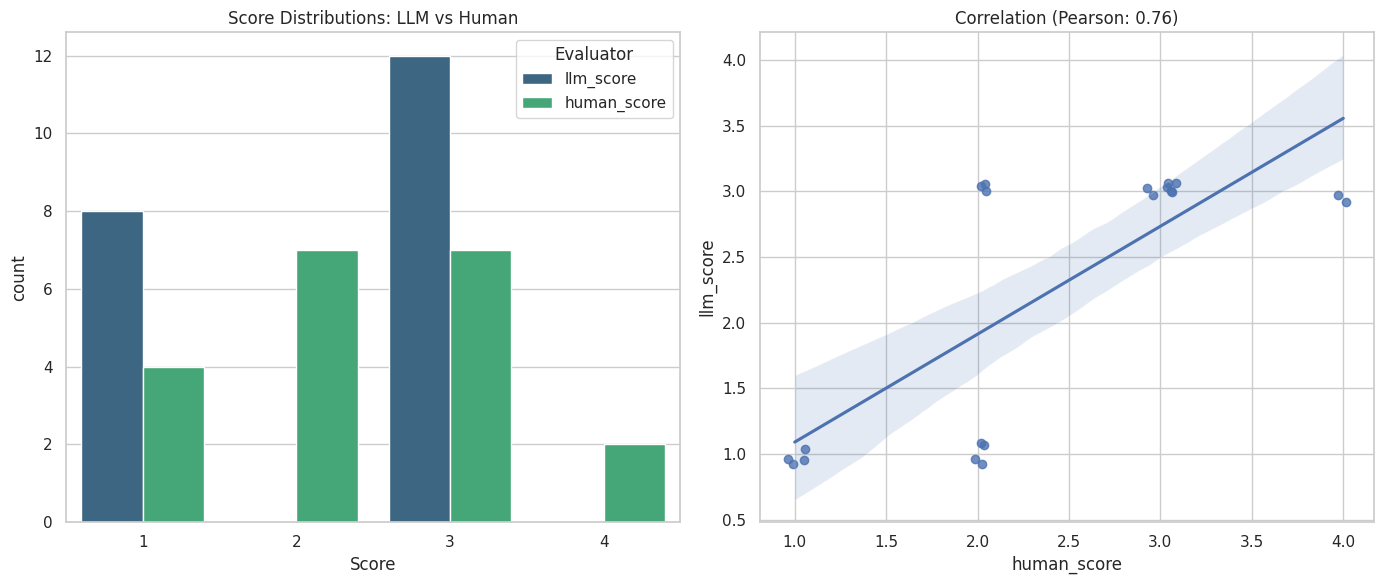

--- Final Evaluation Summary ---
Pearson Correlation: 0.7629
Quadratic Cohen's Kappa: 0.7514

Conclusion: The LLM-as-a-judge shows SUBSTANTIAL alignment with human pedagogical judgment.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style='whitegrid')

# This conclusion is for the HUMAN-VALIDATED SAMPLE only.
if 'df_compare' in globals() and not df_compare.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Distribution Plot (sample only)
    df_melted = df_compare.melt(
        value_vars=['llm_score', 'human_score'],
        var_name='Evaluator',
        value_name='Score'
    )
    sns.countplot(data=df_melted, x='Score', hue='Evaluator', palette='viridis', ax=axes[0])
    axes[0].set_title('Sample Score Distributions: LLM vs Human')

    # Correlation Plot (sample only)
    sns.regplot(data=df_compare, x='human_score', y='llm_score', x_jitter=0.1, y_jitter=0.1, ax=axes[1])
    axes[1].set_title(f'Sample Correlation (Pearson: {pearson:.2f})')

    plt.tight_layout()
    plt.show()

    print('--- Sample Validation Summary (Human vs LLM Judge) ---')
    print(f'Compared rows (sample): {len(df_compare)}')
    print(f'Pearson Correlation: {pearson:.4f}')
    print(f"Quadratic Cohen\'s Kappa: {kappa:.4f}")

    if kappa > 0.6:
        print('\nInterpretation: SUBSTANTIAL agreement on sampled data. Proceed to judge all pairs.')
    else:
        print('\nInterpretation: Agreement is moderate/low. Consider prompt refinement before full-scale judging.')

    print('\nNext step: run the new full-dataset judging cells below to evaluate all fetched pairs.')
else:
    print('Error: df_compare not found. Please run the human-vs-LLM comparison cell first.')

## 6. Full-Dataset LLM Judging

Tujuan:
Jalankan penilaian LLM untuk seluruh pasangan data dengan resume checkpoint.

Langkah:
1. Validasi prasyarat data dan optional quality gate (kappa).
2. Siapkan dataset evaluasi full + fitur bantu (elo_band).
3. Muat checkpoint agar bisa lanjut dari progres terakhir.
4. Skor tiap baris dengan retry + backoff.
5. Simpan checkpoint berkala dan final output ke Google Drive.

In [ ]:
import os
import json
import time
import requests
import pandas as pd
from google.colab import userdata

# ==============================
# 6) Full-Dataset LLM Judging
# ==============================

# Flow config
EVAL_MODEL = 'nvidia/nemotron-3-super-120b-a12b:free'
API_URL = 'https://openrouter.ai/api/v1/chat/completions'
REQUEST_TIMEOUT = 60
SLEEP_SECONDS = 15
MAX_RETRIES = 4
RETRY_BASE_DELAY = 30
SAVE_EVERY = 20
BATCH_LIMIT = None
CHECKPOINT_PATH = os.path.join(GDRIVE_FOLDER, 'llm_judge_all_pairs_results.csv')

# Optional safety gate
REQUIRE_SAMPLE_VALIDATION = False
MIN_KAPPA_TO_PROCEED = 0.6


def validate_prerequisites():
    if REQUIRE_SAMPLE_VALIDATION:
        if 'kappa' not in globals():
            raise ValueError('kappa not found. Run sample validation first or set REQUIRE_SAMPLE_VALIDATION=False.')
        if kappa < MIN_KAPPA_TO_PROCEED:
            raise ValueError(f'kappa={kappa:.4f} < {MIN_KAPPA_TO_PROCEED}. Refine prompt before full judging.')

    if 'df_pairs' not in globals() or df_pairs.empty:
        raise ValueError('df_pairs is empty. Run data fetching and pairing cells first.')

    if 'educational_context_summary' not in df_pairs.columns:
        raise ValueError("Column 'educational_context_summary' is missing. Run MySQL enrichment first.")


def score_one_row(row, headers):
    payload = {
        'model': EVAL_MODEL,
        'messages': [{'role': 'user', 'content': build_prompt(row)}],
    }

    response, err = request_with_retry(payload, headers)
    if response is None:
        return None, None, err

    try:
        content = response.json()['choices'][0]['message']['content']
        score, reason = parse_judge_json(content)
        return score, reason, None
    except Exception as e:
        return None, None, f'Parse error: {e}'


def load_checkpoint(path):
    if not os.path.exists(path):
        print('No checkpoint found. Starting fresh.')
        return [], set()

    df_checkpoint = pd.read_csv(path)
    done = df_checkpoint[df_checkpoint['llm_score_full'].notna()].copy()
    done_ids = set(done['eval_id'].astype(str).tolist())
    done_records = done.to_dict('records')

    print(f'Checkpoint found: {path}')
    print(f'  Already scored (valid): {len(done_ids)} | Rows in file: {len(df_checkpoint)}')
    print('  Rows with errors/null will be retried.')
    return done_records, done_ids


def save_checkpoint(df_full_eval, done_records, new_records, path):
    combined = done_records + new_records
    df_checkpoint_save = pd.DataFrame(combined)
    df_temp = pd.merge(df_full_eval, df_checkpoint_save, on='eval_id', how='left')
    df_temp.to_csv(path, index=False)


validate_prerequisites()
headers = get_openrouter_headers()

# Prepare full evaluation dataset
df_full_eval = df_pairs.copy()
if BATCH_LIMIT is not None:
    df_full_eval = df_full_eval.head(BATCH_LIMIT).copy()

required_cols = ['eval_id', 'user_id', 'user_message', 'chatbot_reply', 'educational_context_summary']
missing_cols = [c for c in required_cols if c not in df_full_eval.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

if 'latest_elo' in df_full_eval.columns:
    df_full_eval['elo_band'] = df_full_eval['latest_elo'].apply(infer_elo_band)

# Resume from checkpoint
done_records, done_ids = load_checkpoint(CHECKPOINT_PATH)
df_todo = df_full_eval[~df_full_eval['eval_id'].astype(str).isin(done_ids)].copy()

print(f'Total pairs: {len(df_full_eval)} | Already done: {len(done_ids)} | To process: {len(df_todo)}')
print(f'Conservative pacing enabled: {SLEEP_SECONDS}s between requests.')

# Main scoring loop
new_results = []
start_time = time.time()
print(f'Start judging {len(df_todo)} remaining pairs using model: {EVAL_MODEL}')

for i, (_, row) in enumerate(df_todo.iterrows(), start=1):
    score, reason, err = score_one_row(row, headers)
    new_results.append({
        'eval_id': row['eval_id'],
        'llm_score_full': score,
        'llm_reason_full': reason if reason else ('N/A' if err else ''),
        'llm_error_full': err,
    })

    if i % SAVE_EVERY == 0 or i == len(df_todo):
        elapsed = time.time() - start_time
        ok = sum(1 for r in new_results if r['llm_score_full'] is not None)
        print(f'Progress: {i}/{len(df_todo)} | success={ok} | elapsed={elapsed:.1f}s')
        save_checkpoint(df_full_eval, done_records, new_results, CHECKPOINT_PATH)

    time.sleep(SLEEP_SECONDS)

# Final merge and persist
all_results = done_records + new_results
df_full_results = pd.DataFrame(all_results)
df_pairs_scored_all = pd.merge(df_full_eval, df_full_results, on='eval_id', how='left')
df_pairs_scored_all.to_csv(CHECKPOINT_PATH, index=False)

success_rate = df_pairs_scored_all['llm_score_full'].notna().mean() * 100
print(f'Finished. Scored rows: {len(df_pairs_scored_all)} | Success rate: {success_rate:.2f}%')
print(f'Saved: {CHECKPOINT_PATH}')
display(df_pairs_scored_all[['eval_id', 'llm_score_full', 'llm_error_full']].head(20))

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


if 'df_pairs_scored_all' not in globals() or df_pairs_scored_all.empty:
    print('Run the full-dataset judging cell first (cell above this summary section).')
else:
    df_ok = df_pairs_scored_all.dropna(subset=['llm_score_full']).copy()
    if df_ok.empty:
        raise ValueError('No valid llm_score_full found. Check API errors in llm_error_full.')

    df_ok['llm_score_full'] = pd.to_numeric(df_ok['llm_score_full'], errors='coerce')
    df_ok = df_ok.dropna(subset=['llm_score_full']).copy()
    df_ok['llm_score_full'] = df_ok['llm_score_full'].round().astype(int)

    if 'latest_elo' in df_ok.columns:
        df_ok['elo_band'] = df_ok['latest_elo'].apply(infer_elo_band)

    summary = {
        'total_pairs_input': len(df_pairs_scored_all),
        'total_pairs_scored': len(df_ok),
        'mean_score': float(df_ok['llm_score_full'].mean()),
        'median_score': float(df_ok['llm_score_full'].median()),
        'std_score': float(df_ok['llm_score_full'].std(ddof=1)) if len(df_ok) > 1 else 0.0,
    }

    print('--- Full-Dataset LLM Judge Summary (LeveLearn) ---')
    for k, v in summary.items():
        print(f'{k}: {v}')

    score_dist = df_ok['llm_score_full'].value_counts().sort_index()
    print('\nScore distribution (1-5):')
    print(score_dist)

    if 'latest_elo' in df_ok.columns:
        tmp = df_ok.copy()
        tmp['latest_elo'] = pd.to_numeric(tmp['latest_elo'], errors='coerce')
        tmp = tmp.dropna(subset=['latest_elo'])
        if not tmp.empty:
            elo_corr = tmp['llm_score_full'].corr(tmp['latest_elo'])
            print(f'\nCorrelation with latest_elo: {elo_corr:.4f}')

    if 'elo_band' in df_ok.columns:
        band_table = (
            df_ok.groupby('elo_band', as_index=False)
            .agg(
                total_pairs=('eval_id', 'count'),
                mean_score=('llm_score_full', 'mean'),
                median_score=('llm_score_full', 'median'),
            )
            .sort_values('mean_score', ascending=False)
        )
        print('\nMean score by ELO band:')
        display(band_table)

    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.countplot(data=df_ok, x='llm_score_full', palette='crest', ax=axes[0])
    axes[0].set_title('LLM Judge Score Distribution (All Pairs)')
    axes[0].set_xlabel('Score')
    axes[0].set_ylabel('Count')

    if 'latest_elo' in df_ok.columns:
        tmp = df_ok.copy()
        tmp['latest_elo'] = pd.to_numeric(tmp['latest_elo'], errors='coerce')
        tmp = tmp.dropna(subset=['latest_elo'])
        if not tmp.empty:
            sns.regplot(data=tmp, x='latest_elo', y='llm_score_full', scatter_kws={'alpha': 0.35}, ax=axes[1])
            axes[1].set_title('LLM Score vs Latest ELO')
            axes[1].set_xlabel('Latest ELO')
            axes[1].set_ylabel('LLM Score')
        else:
            axes[1].axis('off')
    else:
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    df_kpi = pd.DataFrame([summary])
    kpi_path = os.path.join(GDRIVE_FOLDER, 'llm_judge_all_pairs_kpi.csv')
    df_kpi.to_csv(kpi_path, index=False)
    print(f'Saved: {kpi_path}')